In [2]:
import yfinance as yf
import pandas as pd
import time
import pprint

In [3]:
ticker=yf.Ticker("AAPL")
info = ticker.info

In [ ]:
# 전체 구조 출력
pprint.pprint(info)

{'52WeekChange': -0.036207974,
 'SandP52WeekChange': 0.10163462,
 'address1': 'One Apple Park Way',
 'ask': 201.64,
 'askSize': 2,
 'auditRisk': 7,
 'averageAnalystRating': '2.1 - Buy',
 'averageDailyVolume10Day': 56355760,
 'averageDailyVolume3Month': 61356275,
 'averageVolume': 61356275,
 'averageVolume10days': 56355760,
 'beta': 1.211,
 'bid': 201.38,
 'bidSize': 2,
 'boardRisk': 1,
 'bookValue': 4.471,
 'city': 'Cupertino',
 'companyOfficers': [{'age': 63,
                      'exercisedValue': 0,
                      'fiscalYear': 2024,
                      'maxAge': 1,
                      'name': 'Mr. Timothy D. Cook',
                      'title': 'CEO & Director',
                      'totalPay': 16520856,
                      'unexercisedValue': 0,
                      'yearBorn': 1961},
                     {'age': 60,
                      'exercisedValue': 0,
                      'fiscalYear': 2024,
                      'maxAge': 1,
                      'name': 

In [5]:
# 주요 필드 출력
print("\n🔹 주요 필드 요약 🔹")
print("종목명:", info.get('longName'))
print("섹터(Sector):", info.get('sector'))
print("산업군(Industry):", info.get('industry'))
print("설명:", info.get('longBusinessSummary'))
print("시가총액:", info.get('marketCap'))
print("거래소:", info.get('exchange'))
print("PER:", info.get('trailingPE'))
print("EPS:", info.get('trailingEps'))
print("배당률:", info.get('dividendYield'))
print("웹사이트:", info.get('website'))


🔹 주요 필드 요약 🔹
종목명: Apple Inc.
섹터(Sector): Technology
산업군(Industry): Consumer Electronics
설명: Apple Inc. designs, manufactures, and markets smartphones, personal computers, tablets, wearables, and accessories worldwide. The company offers iPhone, a line of smartphones; Mac, a line of personal computers; iPad, a line of multi-purpose tablets; and wearables, home, and accessories comprising AirPods, Apple TV, Apple Watch, Beats products, and HomePod. It also provides AppleCare support and cloud services; and operates various platforms, including the App Store that allow customers to discover and download applications and digital content, such as books, music, video, games, and podcasts, as well as advertising services include third-party licensing arrangements and its own advertising platforms. In addition, the company offers various subscription-based services, such as Apple Arcade, a game subscription service; Apple Fitness+, a personalized fitness service; Apple Music, which offers use

#### 용어 설명
EPS = 순이익/발행 주식 수
- EPS가 높음 -> 성장주, 수익-기대감 분석에 용이

PER = 주가/EPS
- 이익 1달러를 위해 주가 몇 달러를 지불하는가
- 주가수익비율
    - 10 정도의 낮은 PER 수치 -> 저평가/성장 기대 낮음
    - 30~ PER -> 고평가/성장 기대 큼

배당률 = 연간 배당금 / 주가 * 100%
- 투자 금액 대비 매년 얼마를 배당금 받는가
- 배당률이 낮으면 성장 집중, 높으면 안정/보수적 투자 선호

In [6]:
# 위키피디아에서 S&P500 목록 크롤링
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
table = pd.read_html(url)
sp500_df = table[0]

# 티커 리스트
tickers = sp500_df['Symbol'].tolist()

# 일부 티커 포맷 수정 (BRK.B → BRK-B 등)
tickers = [t.replace('.', '-') for t in tickers]

# 결과 저장 리스트
sector_data = []

# 수집 (상위 50개만 예시, 너무 많으면 yfinance 차단됨)
for symbol in tickers[:50]:
    try:
        info = yf.Ticker(symbol).info
        sector = info.get('sector', 'N/A')
        industry = info.get('industry', 'N/A')
        sector_data.append({'Symbol': symbol, 'Sector': sector, 'Industry': industry})
        time.sleep(2)  # rate limit 방지
    except Exception as e:
        print(f"{symbol} 실패: {e}")

# DataFrame으로 정리
sector_df = pd.DataFrame(sector_data)
print(sector_df.head())

  Symbol       Sector                         Industry
0    MMM  Industrials                    Conglomerates
1    AOS  Industrials   Specialty Industrial Machinery
2    ABT   Healthcare                  Medical Devices
3   ABBV   Healthcare     Drug Manufacturers - General
4    ACN   Technology  Information Technology Services


In [7]:
sector_df

,Symbol,Sector,Industry
0,MMM,Industrials,Conglomerates
1,AOS,Industrials,Specialty Industrial Machinery
2,ABT,Healthcare,Medical Devices
3,ABBV,Healthcare,Drug Manufacturers - General
4,ACN,Technology,Information Technology Services
5,ADBE,Technology,Software - Application
6,AMD,Technology,Semiconductors
7,AES,Utilities,Utilities - Diversified
8,AFL,Financial Services,Insurance - Life
9,A,Healthcare,Diagnostics & Research


Communication Services: 통신/미디어/엔터테인먼트

Consumer Discretionary/Cyclical: 임의소비재 (자동차/의류/레저 등 경기변동민감소재)

Consumer Staples/Defensive: 필수소비재 (식료품, 음료, 담배 등 필수 소비재)

Energy: 에너지 (석유, 가스, 석탄, 전기생산 관련 등등)

Financials: 금융 (은행, 보험, 증권)

Health Care: 헬스 케어 (제약, 바이오, 의료 기기)

Industrials: 산업재 (건설, 기계, 항공우주)

Information Technology 정보 기술 (소프트웨어, 하드웨어, 반도체)

Materials: 소재 (금속, 광물, 화학 등 원자재)

Real Estate: 부동산 (개발, 투자, 관리 등)

Utilities: 유틸리티 (전기, 가스, 수도 등 공공 서비스)

RMSE: 285.01


/home/nshawny/anaconda3/envs/dl-gpu/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/nshawny/anaconda3/envs/dl-gpu/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/nshawny/anaconda3/envs/dl-gpu/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/nshawny/anaconda3/envs/dl-gpu/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters foun

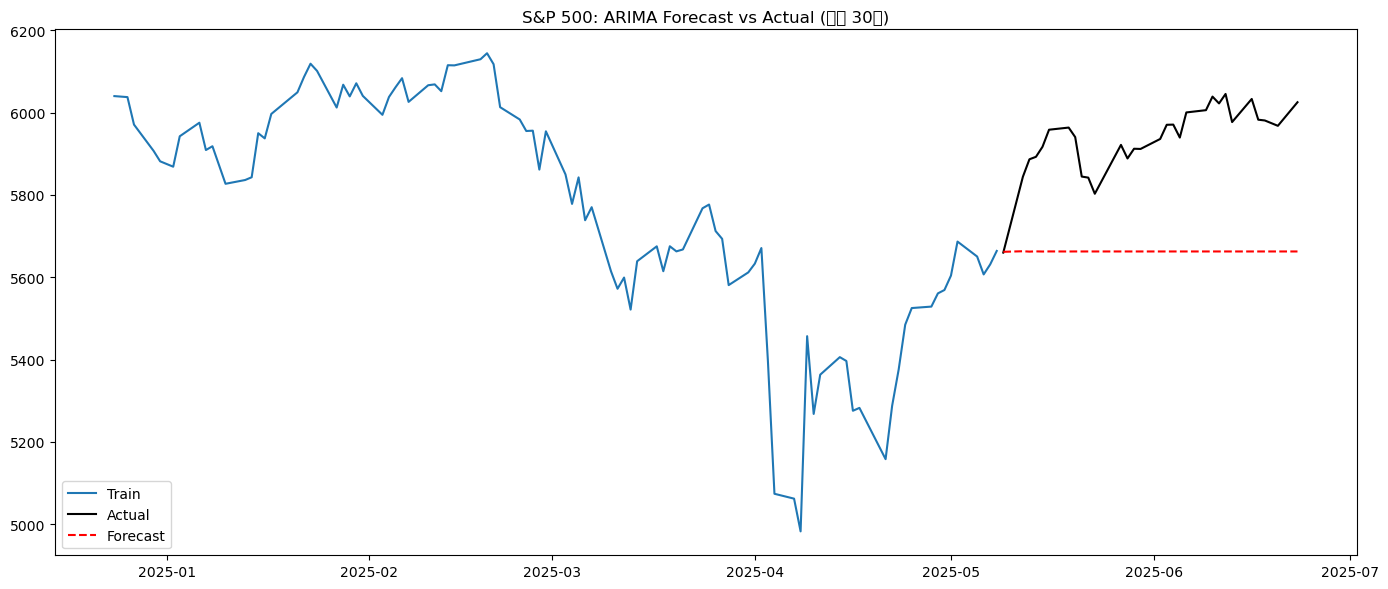

In [11]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. 데이터 불러오기
df = yf.Ticker("^GSPC").history(period="6mo")  # 6개월치 정도
df = df['Close'].dropna()

# 2. 데이터 분할
train = df[:-30]     # 학습용 (30일 전까지)
test = df[-30:]      # 실제 예측 대상

# 3. ARIMA 모델 학습
model = ARIMA(train, order=(1,1,1))  # (p,d,q) 단순 설정
fit = model.fit()

# 4. 예측 수행 (최근 30일치)
forecast = fit.forecast(steps=30)
forecast.index = test.index  # 날짜 맞추기

# 5. RMSE 계산
rmse = np.sqrt(mean_squared_error(test, forecast))
print(f"RMSE: {rmse:.2f}")

# 6. 시각화
plt.figure(figsize=(14, 6))
plt.plot(train, label='Train')
plt.plot(test, label='Actual', color='black')
plt.plot(forecast, label='Forecast', color='red', linestyle='--')
plt.title("S&P 500: ARIMA Forecast vs Actual (최근 30일)")
plt.legend()
plt.tight_layout()
plt.show()

ARIMA 한계 명확. 굉장히 비정상적, 추세 다차항, 계절성 파악하기엔 짧은 구간

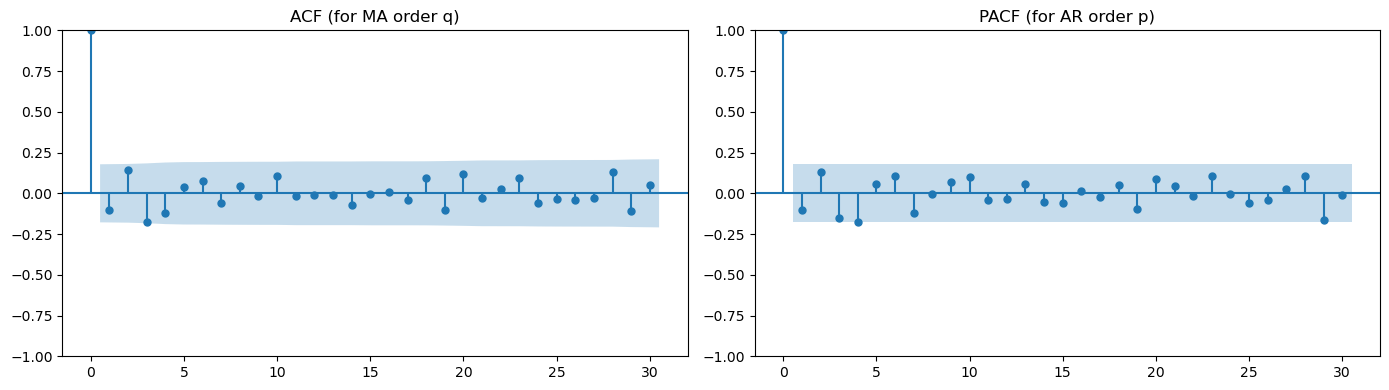

In [16]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 데이터 로드
df = yf.Ticker("^GSPC").history(period="6mo")['Close'].dropna()

# 차분 (d=1)
diff = df.diff().dropna()

# ACF / PACF 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(diff, lags=30, ax=axes[0])
plot_pacf(diff, lags=30, ax=axes[1])
axes[0].set_title("ACF (for MA order q)")
axes[1].set_title("PACF (for AR order p)")
plt.tight_layout()
plt.show()

약한 계절성, 약한 추세